In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(RColorBrewer)
library(tibble)
library(clusterProfiler)
library(pheatmap)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




clusterProfiler v4.14.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

G Yu. Thirteen years of clusterProfiler. The Innovation. 2024,
5(6):100722


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter




In [2]:
# Plot correlations

In [3]:
get_corr_mat<-function(obj, ref, 
                   obj.group.by, ref.group.by,
                      obj.order, ref.order){
    obj <- NormalizeData(obj) %>% FindVariableFeatures() %>% ScaleData()
    ref <- NormalizeData(ref) %>% FindVariableFeatures() %>% ScaleData()
    
    ref@meta.data[[ref.group.by]] <- factor(ref@meta.data[[ref.group.by]], levels = sort(unique(ref@meta.data[[ref.group.by]])))
    
    avg_ref <- as.matrix(AverageExpression(ref, group.by = ref.group.by, assays = "RNA", slot = "scale.data")$RNA)
    avg_obj <- as.matrix(AverageExpression(obj, group.by = obj.group.by, assays = "RNA", slot = "scale.data")$RNA)
        
    # Step 3: Find common genes (intersect rownames)
    common_genes <- intersect(rownames(avg_ref), rownames(avg_obj))
        # Check if there are common genes
    if (length(common_genes) < 2) {
      stop("Insufficient common genes for correlation analysis. Check your data.")
    }

        
    # Step 4: Compute correlation matrix (Spearman is robust for expression data; can change to "pearson")
    cor_mat <- cor(avg_obj[common_genes, ], avg_ref[common_genes, ], method = "spearman")

    'if (obj.order == FALSE){
    # Define the desired all order (using hyphens as per data)
    obj_order <- rev(unique(obj@meta.data[[obj.group.by]]))
    }'
    
    # Reorder the rows of cor_mat to reverse the desired order (to account for pheatmap's y-axis plotting from bottom to top)
    cor_mat <- cor_mat[rev(obj.order), ]
    cor_mat <- cor_mat[, rev(ref.order)]
    
    return(cor_mat)
        
}

options(repr.plot.height=7, repr.plot.width=4)

plot_corr_mat <- function(corr_mat, font=12,
                          colorset = rev(brewer.pal(n = 11, name = "BrBG"))) {
  p <- pheatmap(corr_mat,
                cluster_rows = FALSE,
                cluster_cols = FALSE,
                main = "Correlation Heatmap",
                fontsize = font,
                color = colorset)
  print(p)
}

In [4]:
# VIO correlation with primary lung samples

In [5]:
# Zemin ALK 
zemin <- readRDS("../B1_objects/zemin_lung.rds")
zemin_alk <- subset(zemin, subset = driver_gene == "ALK")

# VIO_reference
VIO<-readRDS(file='/storage/riosugimuralab/alexto/01_MS/F1_VIO.rds')

In [6]:
desired_annotations <- c("MF-Monocytes", "fibroblast", "endothelial", "Mast-cells", "neuro.e cell", 
                        "alveolar type 1 cell", "alveolar type 2 cell", "club cell", "ciliated cell")
Zemin.subset.celltypes <- subset(zemin_alk, subset = Final_annotation %in% desired_annotations)

In [7]:
# Convert to character first to avoid factor level issues, then replace
Zemin.subset.celltypes$Final_annotation <- as.character(Zemin.subset.celltypes$Final_annotation)
Zemin.subset.celltypes$Final_annotation[Zemin.subset.celltypes$Final_annotation == "neuro.e cell"] <- "neurons"

In [8]:
# 1. Fix the string to "neuro.e cell" to match your metadata
VIO.order <- rev(c("MonoMac", "Granulocyte", "Endothelium", "Fibroblast", "Myofibroblast", "Neurons", "Stromal-1", "Stromal-2"))
Zemin.order <- rev(c("MF-Monocytes", "Mast-cells", "endothelial", "fibroblast", "neurons", 
                     "alveolar type 2 cell", "club cell"))

# 2. Change obj from VIO to VIO_ref
cor_mat <- get_corr_mat(
  obj = VIO, 
  ref = Zemin.subset.celltypes, 
  obj.group.by = "cell_type", 
  ref.group.by = "Final_annotation", 
  obj.order = VIO.order, 
  ref.order = Zemin.order
)

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Centering and scaling data matrix

Centering and scaling data matrix

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


scCustomize v3.1.3
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



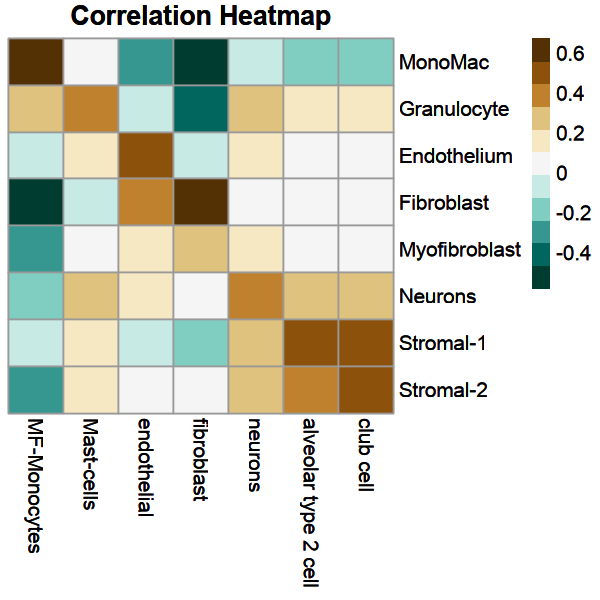

In [9]:
options(repr.plot.height=5, repr.plot.width=5)
library(scCustomize)
plot_corr_mat(corr_mat = cor_mat)

In [17]:
# CIVA correlation with primary lung cancer samples

In [11]:
# Zemin ALK 
zemin <- readRDS("../B1_objects/zemin_lung.rds")
zemin_alk <- subset(zemin, subset = driver_gene == "ALK")

# CIVA reference
all <- readRDS("/storage/riosugimuralab/alexto/A2_AssemFlex/Flex.rds")
CIVA <- subset(all, subset = orig.ident == 'Assembloid')

In [12]:
desired_annotations <- c("MF-Monocytes", "fibroblast",  "Mast-cells", 'tumor')
Zemin.subset.celltypes <- subset(zemin_alk, subset = Final_annotation %in% desired_annotations)

In [13]:
CIVA <- subset(CIVA, subset = !(cell_type %in% c("Mixed", "Unknown_1", "Unknown_2")))

In [14]:
colnames(CIVA@meta.data)
levels(CIVA$cell_type)
unique(Zemin.subset.celltypes$Final_annotation)

[1] "orig.ident"            "nCount_RNA"            "nFeature_RNA"         
[4] "unintegrated_clusters" "seurat_clusters"       "cell_type"

[1] "CD16+ Mac"    "IL1B+ Mac"    "GLUL+ Mac"    "FOLR2+ Mac"   "TREM2+ Mac"  
 [6] "FABP5+ Mac"   "C3+ Mac"      "ISG15+ Mac"   "HK2+ Mac"     "GAS6+ Mac"   
[11] "CSF3R+ Mac"   "NR4A1+ Mac"   "Prolif Mac-1" "Prolif Mac-2" "Prolif Mac-3"
[16] "Mast_cell"    "Fibroblast"   "Endothelium"  "Tumor"

[1] "MF-Monocytes" "tumor"        "fibroblast"   "Mast-cells"

In [15]:
# 1. Define your Zemin reference order (Confirmed working)
Zemin.order<- desired_annotations

# 2. Get CIVA order and swap out the underscore for the hyphen to match the matrix
CIVA.order <- rev(levels(CIVA$cell_type))
CIVA.order <- gsub("Mast_cell", "Mast-cell", CIVA.order)

# 3. Compute the correlation matrix safely
cor_mat <- get_corr_mat(
  obj = CIVA, 
  ref = Zemin.subset.celltypes, 
  obj.group.by = "cell_type", 
  ref.group.by = "Final_annotation", 
  obj.order = CIVA.order, 
  ref.order = Zemin.order
)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
Centering and scaling data matrix

Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


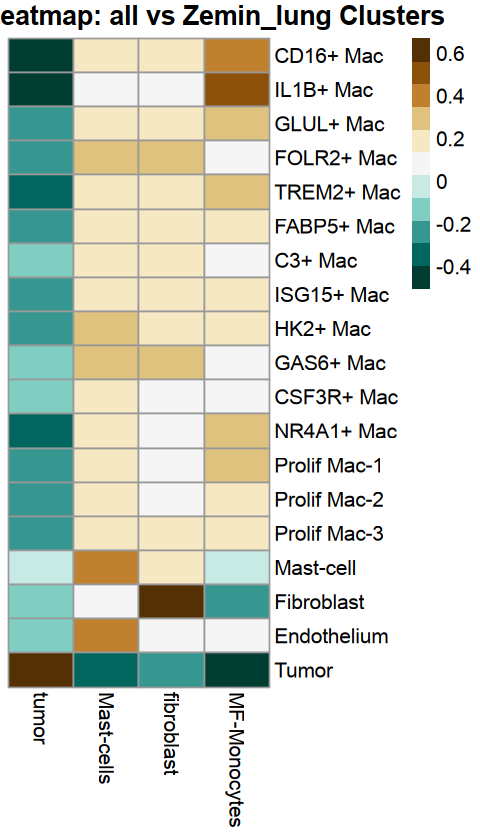

In [16]:
options(repr.plot.height=7, repr.plot.width=4)
pheatmap(cor_mat, 
         cluster_rows = FALSE, 
         cluster_cols = FALSE, 
         main = "Correlation Heatmap: all vs Zemin_lung Clusters",
         fontsize = 12,
         color = rev(brewer.pal(n = 11, name = "BrBG")))